In [ ]:
import numpy as np
import time
from functools import wraps
from time import perf_counter as pc
import matplotlib.pyplot as plt

## run time function

A lightweight decorator-based tool that tracks and aggregates the total execution time of specific functions across the entire program run, providing a clean summary report at the end.


*  Purpose: Monitors total runtime of multiple functions by using the @run_time decorator.
*  Usage: Automatically sums up execution times in the background and displays them only when show_time_results() is called.

**Reihane & Fateme, done**

In [ ]:
# Dictionary to store the cumulative execution time for each decorated function
PROFILE = {}

def run_time(func):
    """
    A decorator that silently accumulates the execution time of a function
    into the global PROFILE dictionary without printing during runtime.
    """
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = pc()                   # Record high-precision start time
        result = func(*args, **kwargs) # Execute the original function
        end = pc()                     # Record high-precision end time

        # Get function name and add the elapsed time to its total
        name = func.__name__
        PROFILE[name] = PROFILE.get(name, 0.0) + (end - start)

        return result
    return wrapper

def show_time_results():
    """
    Prints a formatted summary table of all accumulated times.
    Call this once at the very end of your script.
    """
    print("\n" + "="*45)
    print(f"{'Function Name':<30} | {'Total Time (s)':<10}")
    print("-" * 45)
    for name, duration in PROFILE.items():
        print(f"{name:<30} | {duration:.6f}")
    print("="*45)

##Solver “state container” class (ONLY data + initialization)

In [ ]:
class VlasovPoisson1D1V_PPT:
    """
    1D1V electrostatic Vlasov–Poisson solver using the Phase Point Trajectory (characteristics) method.

    Key idea:
      - Phase points (xp, vp) move along characteristics:
            dx/dt = v
            dv/dt = -E(x,t)
      - The distribution value carried by each phase point, fp, stays constant:
            fp(t) = fp(0)
      - At each time step we reconstruct f on a fixed (x,v) grid using the "method of average",
        compute density, solve Poisson, interpolate E back to phase points, and push them.

    Assumptions / choices in this reference implementation:
      - Periodic boundary in x, solved via FFT Poisson.
      - Velocity domain is truncated and phase-point velocities are clipped into [vmin, vmax].
      - Deposition ("method of average"): nearest-grid-point in phase space (x,v),
        and grid node value is the mean of fp from points assigned to that node.
      - Void grid nodes are filled by neighbor averaging.
    """

    def __init__(
        self,
        nx: int,
        nv: int,
        Lx: float,
        vmin: float,
        vmax: float,
        dt: float,
        ppc: int ,
        void_fill_iterations: int = 2,
        seed: int | None = 0,
        jitter=1, # jitter =0 regular points and jitter=1 random points
    ):
        self.nx = int(nx)
        self.nv = int(nv)
        self.Lx = float(Lx)
        self.vmin = float(vmin)
        self.vmax = float(vmax)
        self.dt = float(dt)
        self.ppc = int(ppc)  # phase points per phase-space "cell"/node neighborhood
        self.void_fill_iterations = int(void_fill_iterations)
        self.jitter = jitter

        rng = np.random.default_rng(seed)

        # Fixed grids
        self.x = np.linspace(0.0, self.Lx, self.nx, endpoint=False)
        self.dx = self.Lx / self.nx

        self.v = np.linspace(self.vmin, self.vmax, self.nv, endpoint=True)
        self.dv = (self.vmax - self.vmin) / (self.nv - 1)

        # Create multiple phase points per (x,v) node neighborhood (Option B: multiple points, jittered)
        # Total Np = nx * nv * ppc -> can get large quickly.
        Np = self.nx * self.nv * self.ppc
        self.xp = np.empty(Np, dtype=float)
        self.vp = np.empty(Np, dtype=float)
        self.fp = np.empty(Np, dtype=float)

        # Place markers: for each (i,j), place ppc points jittered within +/- 0.5 dx, +/- 0.5 dv
        idx = 0
        for i in range(self.nx):
            xi = self.x[i]
            for j in range(self.nv):
                vj = self.v[j]
                for _ in range(self.ppc):

                    if self.jitter:
                        xjitter = (rng.random() - 0.5) * self.dx
                        vjitter = (rng.random() - 0.5) * self.dv
                    else:
                        xjitter = 0.0
                        vjitter = 0.0

                    self.xp[idx] = (xi + xjitter) % self.Lx
                    self.vp[idx] = np.clip(vj + vjitter, self.vmin, self.vmax)
                    idx += 1

        # Leapfrog storage: velocity at half-step
        self.v_half = self.vp.copy()  # will be properly initialized after initial field solve

        # Work arrays (grid quantities)
        self.fg = np.zeros((self.nx, self.nv), dtype=float)
        self.ne = np.zeros(self.nx, dtype=float)
        self.rho = np.zeros(self.nx, dtype=float)
        self.phi = np.zeros(self.nx, dtype=float)
        self.Eg = np.zeros(self.nx, dtype=float)

##Initial condition setter

In [ ]:
@run_time
def set_initial_distribution(solver: VlasovPoisson1D1V_PPT, f0_callable):
    """
    Set fp = f0(xp, vp). fp remains constant in time afterward.
    """
    solver.fp = f0_callable(solver.xp, solver.vp)

#**Deposition (method of average)**

In the Phase Point Trajectories (PPT) method for solving the Vlasov equation, the distribution function is carried by discrete **phase points** ($f_p$). however, to solve the Poisson equation and calculate the electric field, we need the distribution function defined on a **fixed Eulerian mesh** ($f_g$).

The 1D1V Vlasov equation describes the evolution of a distribution function $f(x, v, t)$ in phase space. In the PPT approach:
1. We follow the trajectories of points $(x_p, v_p)$ using the characteristics of the Vlasov equation.
2. Each point carries a value $f_p$ which remains constant along the trajectory (as per Liouville's Theorem for collisionless plasmas).
3. To find the macroscopic **Electron Density** ($n_e$), we must integrate $f$ over velocity space:
   $$n_e(x) = \int f(x,v) \, dv$$
   This integration requires the values of $f$ on a structured grid ($f_g$).

##  The Method of Average
While standard Particle-In-Cell (PIC) codes often use Bilinear Interpolation, this code uses the **Method of Average** .

### The Taylor Expansion Logic
Consider a grid point at $(x, v)$. Suppose there are $N$ phase points in its immediate vicinity. For each phase point $i$, the value $f(x + \Delta x_i, v + \Delta v_i)$ can be expanded using a Taylor series around the grid point $(x, v)$:

$$f(x + \Delta x_i, v + \Delta v_i) = f(x, v) + \left( \frac{\partial f}{\partial x} \right) \Delta x_i + \left( \frac{\partial f}{\partial v} \right) \Delta v_i + O(\Delta^2)$$

If we sum this expression over all $N$ phase points and divide by $N$, we get the **average**:

$$\frac{1}{N} \sum_{i=1}^N f(x + \Delta x_i, v + \Delta v_i) = f(x, v) + \frac{\partial f}{\partial x} \left( \frac{1}{N} \sum \Delta x_i \right) + \frac{\partial f}{\partial v} \left( \frac{1}{N} \sum \Delta v_i \right) + \dots$$

**The core assumption:** As the number of phase points $N$ increases, and if they are distributed somewhat symmetrically around the grid point, the terms $(\frac{1}{N} \sum \Delta x_i)$ and $(\frac{1}{N} \sum \Delta v_i)$ tend toward zero. Therefore:

$$f_g(x, v) \approx \frac{1}{N} \sum_{i=1}^N f_p^{(i)}$$

This method is computationally efficient because it avoids the weight calculations required by bilinear interpolation.


**Haniye & Fateme, done**

In [ ]:
@run_time
def deposit_method_of_average(solver: VlasovPoisson1D1V_PPT):
    """
    Reconstruct fg[i,j] on the (x,v) mesh from phase points using "method of average":

      - Assign each phase point to the nearest (i,j) grid node in phase space.
      - For each grid node, fg = mean(fp) of points assigned there.
      - If a node receives no points (void), fill it later.
    """
    fg_sum = np.zeros_like(solver.fg)
    fg_cnt = np.zeros_like(solver.fg)

    # xp -> nearest x index (periodic)
    i = np.rint(solver.xp / solver.dx).astype(int) % solver.nx

    # vp -> nearest v index (clamped)
    j = np.rint((solver.vp - solver.vmin) / solver.dv).astype(int)
    j = np.clip(j, 0, solver.nv - 1)

    # Scatter-add sums and counts
    np.add.at(fg_sum, (i, j), solver.fp)
    np.add.at(fg_cnt, (i, j), 1.0)

    # Average where count>0
    solver.fg.fill(0.0)
    mask = fg_cnt > 0
    solver.fg[mask] = fg_sum[mask] / fg_cnt[mask]

### **Void filling**

A **void** occurs when a region of the Eulerian mesh becomes empty because no phase points are located within the vicinity of a grid node. Numerically, this causes the distribution function $f_g$ to drop to zero abruptly. These "artificial holes" create non-physical discontinuities in the electron density $n_e$, leading to:
*   Inaccurate electric field calculations in the **Poisson Solver**.
*   Numerical instabilities that violate energy conservation.
*   Spurious oscillations in the simulation.

###  Laplacian-style Smoothing
To fix these voids, the code treats the missing data as a local interpolation problem. The strategy is to fill the void by taking the average of its nearest non-void neighbors.

Mathematically, this is a discrete approximation of a **Laplacian smoothing** process. If $f(x,v)$ is missing at a grid point, we assume the distribution function is locally smooth and estimate it using a 4-point stencil (the neighbors in $+x, -x, +v,$ and $-v$):

$$f_{void} \approx \frac{1}{M} \sum_{k=1}^{M} f_{neighbor, k}$$

Where $M$ is the number of available neighbors.

**Haniye & Fateme, done**

In [ ]:
@run_time
def fill_voids_neighbor_average(solver, void_mask):
    """
    Fill empty (x,v) grid cells by averaging nearest neighbors.
    Standalone helper: operates on solver.fg directly.
    """

    if not np.any(void_mask):
        return

    fg = solver.fg
    nx, nv = solver.nx, solver.nv

    for _ in range(solver.void_fill_iterations):
        if not np.any(void_mask):
            break

        new_fg = fg.copy()
        void_indices = np.argwhere(void_mask)

        for (i, j) in void_indices:
            neighbors = [
                fg[(i - 1) % nx, j],
                fg[(i + 1) % nx, j],
            ]
            if j > 0:
                neighbors.append(fg[i, j - 1])
            if j < nv - 1:
                neighbors.append(fg[i, j + 1])

            new_fg[i, j] = np.mean(neighbors) if neighbors else 0.0

        fg[:] = new_fg
        void_mask[:] = False  # one pass is enough for now

Density computation

**Zahra Zarkooee, done**


In [ ]:
@run_time
def compute_density_trapezoid(solver: VlasovPoisson1D1V_PPT):
    """
    ne(x_i) = ∫ f(x_i,v) dv using trapezoidal rule on the v-grid.
    """
    solver.ne = np.sum(0.5 * (solver.fg[:, :-1] + solver.fg[:, 1:]) * solver.dv, axis=1)

## Poisson solver (periodic FFT)

Spectral Solution of the Periodic Poisson Equation

We consider the one-dimensional Poisson equation with periodic boundary conditions,
\begin{equation}
\frac{d^2 \phi(x)}{dx^2} = \rho(x), \qquad \rho(x) = n_e(x) - 1 ,
\end{equation}
where the ion background density is normalized to unity.

Due to periodicity, the potential and charge density are expanded in Fourier series:
\begin{equation}
\phi(x) = \sum_k \phi_k e^{ikx}, \qquad
\rho(x) = \sum_k \rho_k e^{ikx},
\end{equation}
with wave numbers
\begin{equation}
{k} = 2\pi n / L
\end{equation}

Using
\begin{equation}
\frac{d^2}{dx^2} e^{ikx} = -k^2 e^{ikx},
\end{equation}
the Poisson equation in Fourier space becomes
\begin{equation}
- k^2 \phi_k = \rho_k .
\end{equation}

For nonzero modes (\( k \neq 0 \)), the solution is
\begin{equation}
\phi_k = -\frac{\rho_k}{k^2}.
\end{equation}
The zero mode requires global charge neutrality,
\begin{equation}
\rho_0 = \frac{1}{L}\int_0^L \rho(x)\,dx = 0,
\end{equation}
and the gauge is fixed by setting \( \phi_0 = 0 \).

The electric field is obtained from
\begin{equation}
E(x) = -\frac{d\phi}{dx},
\end{equation}
which in Fourier space gives
\begin{equation}
E_k = -ik \phi_k .
\end{equation}

The physical-space fields are finally recovered by inverse Fourier transformation.


**Zahra Zarkooee, done**


In [ ]:
@run_time
def solve_poisson_periodic_fft(solver: VlasovPoisson1D1V_PPT):
    """

    Periodic Poisson:
       phi_xx = rho,  rho = ne - 1 (immobile ion background = 1)

    In Fourier space:
       -(k^2) phi_k = rho_k  =>  phi_k = -rho_k / k^2   for k != 0
       phi_0 set to 0 (gauge: zero-mean potential)

    Electric field:
       E = -phi_x
       E_k = -(i k) phi_k
    """
    # --------------------------------------------------------
    # 1. Charge density
    # --------------------------------------------------------
    # rho(x) = n_e(x) - n_i
    # Ion background density n_i = 1 (normalized units)
    solver.rho = solver.ne - 1.0

     # --------------------------------------------------------
    # 2. Enforce global charge neutrality
    # --------------------------------------------------------
    # For periodic Poisson equation, the zero Fourier mode
    # requires:
    #
    #     ∫ rho(x) dx = 0
    #
    # Numerically, this means mean(rho) must be zero.
    solver.rho -= np.mean(solver.rho)

    # --------------------------------------------------------
    # 3. Fourier transform of charge density
    # --------------------------------------------------------
    rho_k = np.fft.fft(solver.rho)

    # --------------------------------------------------------
    # 4. Wavenumber array
    # --------------------------------------------------------
    # k = 2*pi*n / L
    # fftfreq returns frequencies compatible with FFT ordering
    k = 2.0 * np.pi * np.fft.fftfreq(solver.nx, d=solver.dx)

    # --------------------------------------------------------
    # 5. Solve Poisson equation in Fourier space
    # --------------------------------------------------------
    phi_k = np.zeros_like(rho_k, dtype=complex)

    nonzero = (k != 0.0)

    # For k != 0:
    #   phi_k = - rho_k / k^2
    phi_k[nonzero] = -rho_k[nonzero] / (k[nonzero] ** 2)

    # For k = 0:
    #   phi_0 is arbitrary (gauge freedom)
    #   We choose phi_0 = 0
    phi_k[~nonzero] = 0.0 + 0.0j

    # --------------------------------------------------------
    # 6. Electric field in Fourier space
    # --------------------------------------------------------
    # E(x) = - dphi/dx
    # In Fourier space: d/dx -> i k
    # Therefore: E_k = - i k phi_k
    E_k = -(1j * k) * phi_k

    # --------------------------------------------------------
    # 7. Inverse FFT to physical space
    # --------------------------------------------------------
    # Imaginary parts are numerical round-off errors
    solver.phi = np.real(np.fft.ifft(phi_k))
    solver.Eg  = np.real(np.fft.ifft(E_k))

##E-field extrapolation to phase points (timed)

This function calculates the electric field ($E_p$) at the exact phase-space coordinates $(x_p, v_p)$ for each simulation particle.

The electric field is extrapolated from the grid to the phase points using a *Bilinear Interpolation* scheme within the phase space $(x, v)$.

The function calculates weights for both spatial ($N_x$) and velocity ($N_v$) coordinates. The final field value at each phase point is determined by the weighted sum of the electric field values at the four surrounding grid nodes.

$$ E_p = \sum_{corners} \left( N_x(x) \cdot N_v(v) \cdot E_{grid} \right) $$

**Reihane & Fateme,done**

In [ ]:
@run_time
def extrapolate_E_to_phasepoints(solver: VlasovPoisson1D1V_PPT) -> np.ndarray:
    """
    Extrapolate electric field to phase points using bilinear weights.
    """

    # --- x-direction weights ---
    rx = solver.xp / solver.dx
    ix = np.floor(rx).astype(int) % solver.nx
    ix_next = (ix + 1) % solver.nx

    dx_frac = rx - np.floor(rx)
    Nx1 = 1.0 - dx_frac
    Nx2 = dx_frac

    # --- v-direction weights ---
    rv = (solver.vp - solver.vmin) / solver.dv
    iv = np.floor(rv).astype(int)
    dv_frac = rv - np.floor(rv)

    Nv1 = 1.0 - dv_frac
    Nv2 = dv_frac

    # --- field at left/right x-nodes ---
    E_left = solver.Eg[ix]
    E_right = solver.Eg[ix_next]

    # --- bilinear combination (E depends only on x) ---
    Ep = (Nx1 * Nv1 * E_left +  Nx1 * Nv2 * E_left + Nx2 * Nv1 * E_right + Nx2 * Nv2 * E_right)

    return Ep

##Leapfrog initialization

This section implements the core physics and numerical integration of the Vlasov-Poisson solver based on the **Phase Point Trajectories** method.

### 1. Timing Decorator (`@measure_time`)
To analyze the computational cost, a decorator is defined to measure and accumulate the execution time of the initialization and stepping functions. This helps in identifying bottlenecks (e.g., whether the Poisson solver or particle pushing consumes more time).

### 2. Initialization (`initialize_leapfrog`)
The **Leapfrog** scheme is a time-staggered method where:
*   Position ($x$) is defined at integer time steps ($t, t+\Delta t, ...$).
*   Velocity ($v$) is defined at half-integer time steps ($t+\Delta t/2, ...$).

At $t=0$, we only have $x^0$ and $v^0$. To start the loop, we must push the velocity backward (or adjust it) by half a time step. According to the characteristic equation of motion for electrons ($\frac{dv}{dt} = -E$):

$$ v^{-1/2} = v^0 - \frac{\Delta t}{2} E(x^0) $$

**Correction:** The code ensures the acceleration term has the correct **negative sign** ($-E$), consistent with the physics of negatively charged electrons.

### 3. Time Step (`step`)
This function advances the system by one full time step ($\Delta t$). It follows the cycle described in the reference PDF (Page 20):

1.  **Drift:** Particles move freely based on their velocity.
    $$ x^{n+1} = x^n + v^{n+1/2} \Delta t $$
2.  **Reconstruction (Method of Average):** The distribution function $f_g$ on the fixed grid is reconstructed from the moving phase points ($f_p$).
3.  **Poisson Solve:** The electron density $n_e$ is computed, and Poisson's equation is solved to find the new Electric Field ($E_g$).
4.  **Interpolation:** The field is mapped from grid nodes back to the exact particle positions ($E_p$).
5.  **Kick:** Particles are accelerated by the electric field.
    $$ v^{n+3/2} = v^{n+1/2} - E^{n+1} \Delta t $$

**Zahra ahaninpanjeh, done**

In [ ]:
@run_time
def initialize_leapfrog(solver: VlasovPoisson1D1V_PPT):
    """
    Leapfrog initialization:
      - Compute initial field from initial fp
      - Then set v_half = v(t=0) - (dt/2)*E(x(t=0))
    """
    deposit_method_of_average(solver)
    compute_density_trapezoid(solver)
    solve_poisson_periodic_fft(solver)
    Ep0 = extrapolate_E_to_phasepoints(solver)

    # v^{1/2} = v^0 + (dt/2) E(x^0)
    solver.v_half = solver.vp - 0.5 * solver.dt * Ep0

##One time step (drift–solve–kick)

In [ ]:
@run_time
def step(solver: VlasovPoisson1D1V_PPT):
    """
    One time step:
      1) Drift: x^{n+1} = x^n + dt * v^{n+1/2}
      2) Rebuild f-grid (method of average)
      3) Compute ne and solve Poisson -> Eg
      4) Interpolate field -> Ep
      5) Kick: v^{n+3/2} = v^{n+1/2} - dt * Ep
      6) Update vp (for diagnostics/output)
    """
    # 1) Drift
    solver.xp = (solver.xp + solver.dt * solver.v_half) % solver.Lx

    # 2) Field solve from rebuilt distribution
    deposit_method_of_average(solver)

    # -----Void filling -----
    void_mask = (solver.fg == 0.0)
    fill_voids_neighbor_average(solver, void_mask)

    # 3) Compute ne and solve Poisson
    compute_density_trapezoid(solver)
    solve_poisson_periodic_fft(solver)

    # 4) Interpolate
    Ep = extrapolate_E_to_phasepoints(solver)

    # 5) Kick
    solver.v_half = solver.v_half - solver.dt * Ep

    # Velocity-domain handling: clip (simple)
    solver.v_half = np.clip(solver.v_half, solver.vmin, solver.vmax)

    # 6) Centered velocity proxy for output/diagnostics
    solver.vp = solver.v_half.copy()

##functions

**Zeinab,Mr.Zaraei, Reihane & Fateme, done**

This function calculates the total mass (or particle count) of the system by numerically integrating the distribution function on the grid.

In [ ]:
@run_time
def total_mass_grid(solver: VlasovPoisson1D1V_PPT) -> float:
    """
    Total mass on the grid: ∫∫ f dx dv.
    """
    return float(np.sum(solver.fg) * solver.dx * solver.dv)

This function calculates the total electrostatic potential energy by integrating the square of the electric field over the spatial domain.

$$E_l = \int \frac{1}{2} E_x^2(x) \, dx$$


In [ ]:
@run_time
def Electrostatic_energy(solver: VlasovPoisson1D1V_PPT) -> float:
    """
    Electrostatic energy: U = ∫ E^2/2 dx
    """
    return float(0.5 * np.sum(solver.Eg**2) * solver.dx)

This function calculates the total kinetic energy from the grid distribution by integrating the product of the distribution function and the square of the velocity over the entire phase-space.

$$E_k = \iint \frac{1}{2} f_g(x, v_x) v_x^2 \, dv_x \, dx$$

In [ ]:
@run_time
def kinetic_energy_grid(solver: VlasovPoisson1D1V_PPT) -> float:
    """
    Kinetic Energy calculated from the Grid distribution (fg).
    Matches Eq. 21 of Kazeminezhad et al. (2003).

    Formula: Ek = 0.5 * ∫∫ fg(x,v) * v^2 * dv * dx
    Discrete: Ek ≈ 0.5 * Σ (fg * v^2) * dx * dv
    """
    # solver.fg shape is (nx, nv)
    # solver.v shape is (nv,)

    # Broadcasting v^2 to match the shape of fg (automatically handles (nx, nv))
    integral = np.sum(solver.fg * (solver.v**2))

    return float(0.5 * integral * solver.dx * solver.dv)

The total energy of the system is the sum of the kinetic energy of the particles and the electrostatic field energy. This function implements the following conservation equations:

$$E_k = \iint \frac{1}{2} f_g(x, v_x) v_x^2 \, dv_x \, dx$$

$$E_l = \int \frac{1}{2} E_x^2(x) \, dx$$

$$E_t = E_k + E_l$$

Where:
*   **$E_k$** is the Kinetic Energy.
*   **$E_l$** is the Electrostatic (Potential) Energy.
*   **$E_t$** is the Total Energy of the system.

In [ ]:
@run_time
def total_energy(solver: VlasovPoisson1D1V_PPT) -> float:
    """
    Total energy = kinetic (grid) + Electrostatic energy.
    """
    return kinetic_energy_grid(solver) + Electrostatic_energy(solver)

This function calculates the **Internal Energy** ($E_i$), which represents the thermal energy of the plasma. It measures the kinetic energy associated with the random motion of particles relative to the local mean (drift) velocity.

**1. Local Mean Velocity (First Velocity Moment):**
The local drift velocity $\langle v_x \rangle$ at each position $x$ is defined as:
$$\langle v_x \rangle = \frac{1}{n_e} \int f_g(v_x) v_x \, dv_x$$

**2. Internal Energy Formula:**
The total internal energy is calculated by integrating the squared deviation of particle velocities from the local mean over the entire phase space:
$$E_i = \iint \frac{1}{2} f_g(x, v_x) (v_x - \langle v_x \rangle)^2 \, dv_x \, dx$$

**Where:**
*   **$\langle v_x \rangle$**: The local mean velocity of the particles.
*   **$n_e(x)$**: The local electron number density.
*   **$E_i$**: The total internal (thermal) energy. This serves as a critical diagnostic for checking momentum conservation and the numerical stability of the simulation.

In [ ]:
@run_time
def internal_energy(solver: VlasovPoisson1D1V_PPT) -> float:
    """
    Calculates the Internal Energy (Ei), also known as Thermal Energy.
    This corresponds to the second moment of velocity relative to the local drift.
    """

    # Calculate the local mean velocity <v_x> for every spatial point x
    # Formula: <v_x>(x) = (1/ne) * ∫ f(x,v) * v * dv
    # solver.fg is (nx, nv), solver.v is (nv,)
    momentum_density = np.sum(solver.fg * solver.v, axis=1) * solver.dv

    # Use a small epsilon (1e-15) to prevent division by zero in empty regions
    v_avg = momentum_density / (solver.ne + 1e-15)

    # Calculate the integrand: 0.5 * f * (v - <v>)^2
    # We use broadcasting to subtract the 1D v_avg from the 2D velocity space
    # v_diff shape will be (nx, nv)
    v_diff = solver.v[np.newaxis, :] - v_avg[:, np.newaxis]
    integrand = 0.5 * solver.fg * (v_diff**2)

    #  Perform the double integration over phase space (dx and dv)
    Ei = np.sum(integrand) * solver.dv * solver.dx

    return float(Ei)

In [ ]:
@run_time
def show_recurrence_time(solver, dt):
    delta_v = (solver.vmax - solver.vmin) / solver.nv
    k = 2.0 * np.pi  / solver.Lx

    TR = 2.0 * np.pi / (k * delta_v)

    print(f"Recurrence time TR = {TR:.4f}")
    print(f"Steps to recurrence ≈ {TR/dt:.1f}")

## main

In [ ]:
# Problem size (Np = nx*nv*ppc can get large quickly)
nx, nv = 32,32
Lx =4 * np.pi
vmin, vmax = -5.0, 5.0
dt = 0.05
ppc = 10

solver = VlasovPoisson1D1V_PPT(nx, nv, Lx, vmin, vmax, dt, ppc=ppc, seed=1)

# Example: weakly perturbed Maxwellian (Landau damping style)
alpha = 0.1
k0 = 1.0

def f0(x, v):
    # Maxwellian in v times small sinusoidal perturbation in x
    return (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * v**2) * (1.0 + alpha * np.cos(k0 * x))

set_initial_distribution(solver, f0)
initialize_leapfrog(solver)

# Track relative total energy and relative energy error (page 26 style)
time_list = []
rel_energy = []          # E(t)/E0
rel_energy_err_pct = []  # 100*|E(t)-E0|/E0
E0 = total_energy(solver) # initially before changing solver
log_rho_max = []
show_recurrence_time(solver, dt)

Recurrence time TR = 40.2124
Steps to recurrence ≈ 804.2


## main loop

In [ ]:

nsteps = 800
for n in range(nsteps):
    step(solver)

    t = (n + 1) * dt
    Et = total_energy(solver)

    time_list.append(t)
    log_rho_max.append(np.log(np.max(np.abs(solver.rho))))
    rel_energy.append(Et / E0)
    rel_energy_err_pct.append(100.0 * abs(Et - E0) / abs(E0))

    if n % 20 == 0:
        print(
            f"step={n:4d}  mass(grid)={total_mass_grid(solver):.6e}  "
            f"Electrostatic_energy={Electrostatic_energy(solver):.6e}  "
            f"rel_E={rel_energy[-1]:.8f}  "
            f"rel_err%={rel_energy_err_pct[-1]:.6f}"
        )

show_time_results()
show_recurrence_time(solver, dt)

step=   0  mass(grid)=1.257269e+01  Electrostatic_energy=3.155630e-02  rel_E=0.99987716  rel_err%=0.012284
step=  20  mass(grid)=1.256808e+01  Electrostatic_energy=2.352968e-03  rel_E=0.99837685  rel_err%=0.162315
step=  40  mass(grid)=1.257000e+01  Electrostatic_energy=1.165237e-03  rel_E=0.99893741  rel_err%=0.106259
step=  60  mass(grid)=1.256196e+01  Electrostatic_energy=6.886836e-05  rel_E=0.99869455  rel_err%=0.130545
step=  80  mass(grid)=1.256163e+01  Electrostatic_energy=1.011727e-04  rel_E=0.99905648  rel_err%=0.094352
step= 100  mass(grid)=1.255758e+01  Electrostatic_energy=8.654344e-05  rel_E=0.99776522  rel_err%=0.223478
step= 120  mass(grid)=1.256401e+01  Electrostatic_energy=5.351755e-05  rel_E=0.99784800  rel_err%=0.215200
step= 140  mass(grid)=1.257015e+01  Electrostatic_energy=5.316889e-05  rel_E=0.99844305  rel_err%=0.155695
step= 160  mass(grid)=1.256326e+01  Electrostatic_energy=9.279518e-05  rel_E=0.99825828  rel_err%=0.174172
step= 180  mass(grid)=1.257499e+01  E

## plots

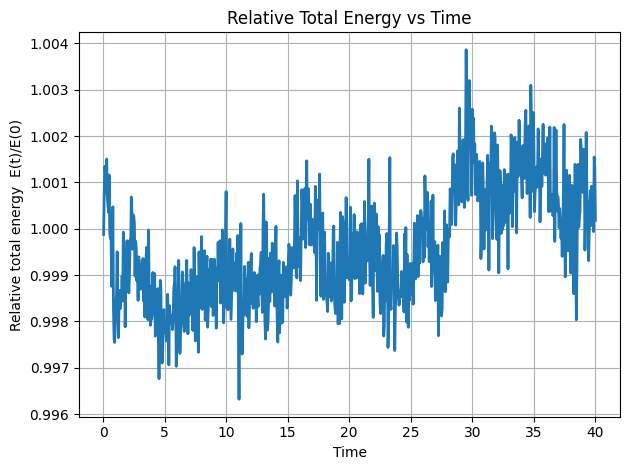

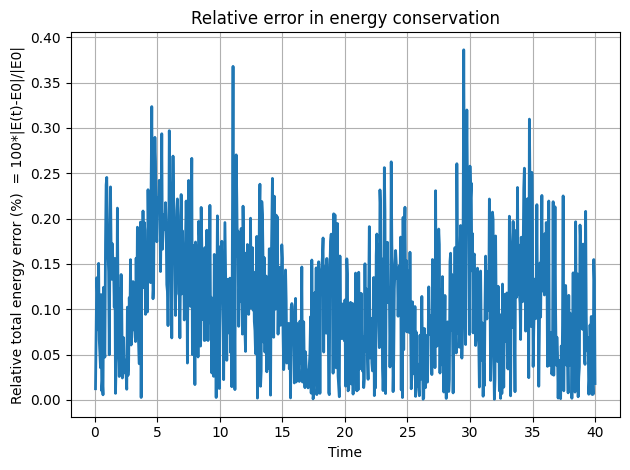

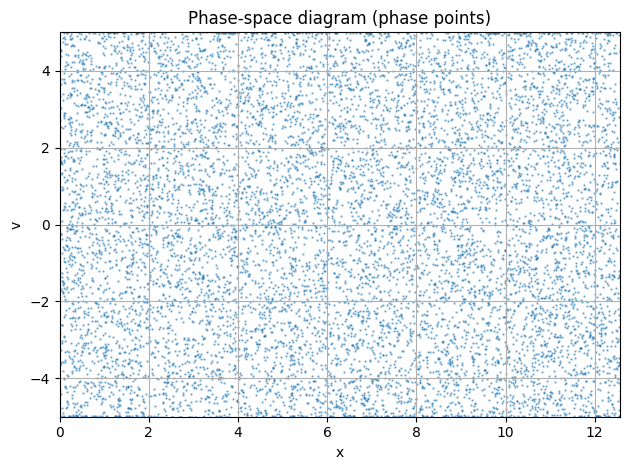

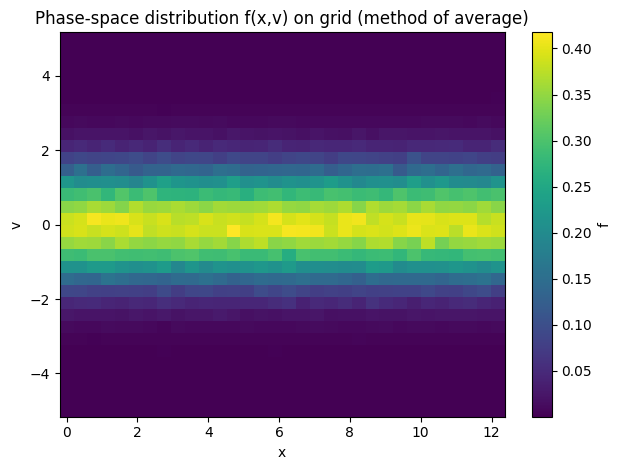

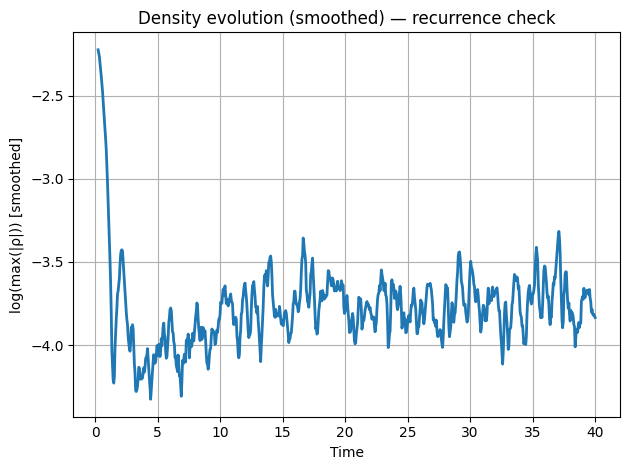

In [ ]:
# Plot: relative total energy vs time
plt.figure()
plt.plot(time_list, rel_energy, lw=2)
plt.xlabel("Time")
plt.ylabel("Relative total energy  E(t)/E(0)")
plt.title("Relative Total Energy vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot: relative energy conservation error (page 26 style)
plt.figure()
plt.plot(time_list, rel_energy_err_pct, lw=2)
plt.xlabel("Time")
plt.ylabel("Relative total energy error (%)  = 100*|E(t)-E0|/|E0|")
plt.title("Relative error in energy conservation")
plt.grid(True)
plt.tight_layout()
plt.show()

# Phase-space scatter plot (phase points)
plt.figure()
plt.scatter(solver.xp, solver.vp, s=0.5, alpha=0.5)
plt.xlabel("x")
plt.ylabel("v")
plt.title("Phase-space diagram (phase points)")
plt.xlim(0, Lx)
plt.ylim(vmin, vmax)
plt.grid(True)
plt.tight_layout()
plt.show()

# Phase-space distribution fg(x,v) on grid
plt.figure()
plt.pcolormesh(solver.x, solver.v, solver.fg.T, shading="auto")
plt.xlabel("x")
plt.ylabel("v")
plt.title("Phase-space distribution f(x,v) on grid (method of average)")
plt.colorbar(label="f")
plt.tight_layout()
plt.show()

# smooth rho vs time
window = 5
log_rho_smooth = np.convolve(log_rho_max, np.ones(window)/window, mode="valid")
plt.figure()
plt.plot(time_list[window-1:], log_rho_smooth, lw=2)
plt.xlabel("Time")
plt.ylabel("log(max(|ρ|)) [smoothed]")
plt.title("Density evolution (smoothed) — recurrence check")
plt.grid(True)
plt.tight_layout()
plt.show()

##PPC scan (conference-style curve)

### code

This code performs a **convergence study** by measuring the maximum energy conservation error across various phase point densities (PPC). It demonstrates how increasing the number of particles per cell improves the numerical accuracy and stability of the Vlasov-Poisson simulation.

**Reihane & Fateme, done**

In [ ]:
# ---------------------------------------------------------
# PPC Scan: Energy Error Study
# ---------------------------------------------------------

ppc_list = [1, 2, 4, 9, 16, 25, 36, 64, 100]
max_errors_pct = []

print(f"{'PPC':<10} | {'Max Energy Error (%)':<20}")
print("-" * 35)

for p in ppc_list:
    solver = VlasovPoisson1D1V_PPT(nx, nv, Lx, vmin, vmax, dt, ppc=p, seed=1)
    set_initial_distribution(solver, f0)
    initialize_leapfrog(solver)

    E0 = total_energy(solver)
    peak_err = 0.0

    # Run steps to find the maximum energy deviation
    for _ in range(400):
        step(solver)
        rel_err = abs(total_energy(solver) - E0) / abs(E0)
        if rel_err > peak_err:
            peak_err = rel_err

    max_errors_pct.append(peak_err * 100)
    print(f"{p:<10} | {max_errors_pct[-1]:<20.6f}")

PPC        | Max Energy Error (%)
-----------------------------------
1          | 12.453736           
2          | 3.114509            
4          | 1.621699            
9          | 0.752318            
16         | 0.492724            
25         | 0.332223            
36         | 0.233451            
64         | 0.101921            
100        | 0.083627            


### plot

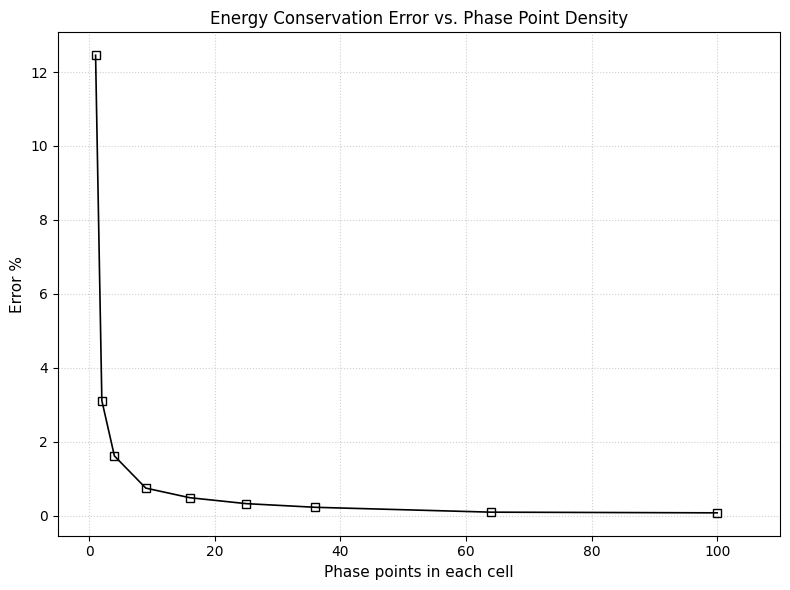

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(ppc_list, max_errors_pct, 's-', color='black', linewidth=1.2, markersize=6, markerfacecolor='none')
plt.xlabel('Phase points in each cell', fontsize=11)
plt.ylabel('Error %', fontsize=11)
plt.title('Energy Conservation Error vs. Phase Point Density', fontsize=12)
plt.xlim(-5, 110)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Convergence Analysis: Energy Conservation

In a perfectly collisionless plasma governed by the Vlasov-Poisson equations, the Total Energy of the system is a conserved quantity (it should remain constant over time). Monitoring the energy conservation is the standard for verifying the accuracy and stability of a plasma simulation.

The total energy ($\mathcal{E}$) in this 1D1V electrostatic system consists of two parts:
1.  Kinetic Energy ($KE$): The energy carried by the motion of the phase points.
   
2.  Potential (Field) Energy ($PE$): The energy stored in the self-consistent electric field.


In a high-quality simulation, the exchange between Kinetic and Potential energy (such as during Landau Damping or Two-Stream Instability) should be seamless, with the sum $KE + PE$ remaining constant.

The code calculates the Relative Total Energy Error % to quantify the numerical "drift."
$$\text{Relative Error} (\%) = 100 \times \frac{|\mathcal{E}(t) - \mathcal{E}_0|}{|\mathcal{E}_0|}$$

Where:
*   $\mathcal{E}_0$ is the total energy at $t=0$.
*   $\mathcal{E}(t)$ is the total energy at the current time step.


By increasing the PPC (Phase Points per Cell), we improve the simulation in two ways:
1.  Better Sampling: We represent the continuous distribution function $f(x,v)$ with higher resolution, reducing "sampling noise."
2.  Vanishing Error Terms: As shown in the "Method of Average" derivation , the higher-order error terms in the reconstruction of $f_g$ vanish as the number of points $N$ increases.

**Haniye & Fateme,done**

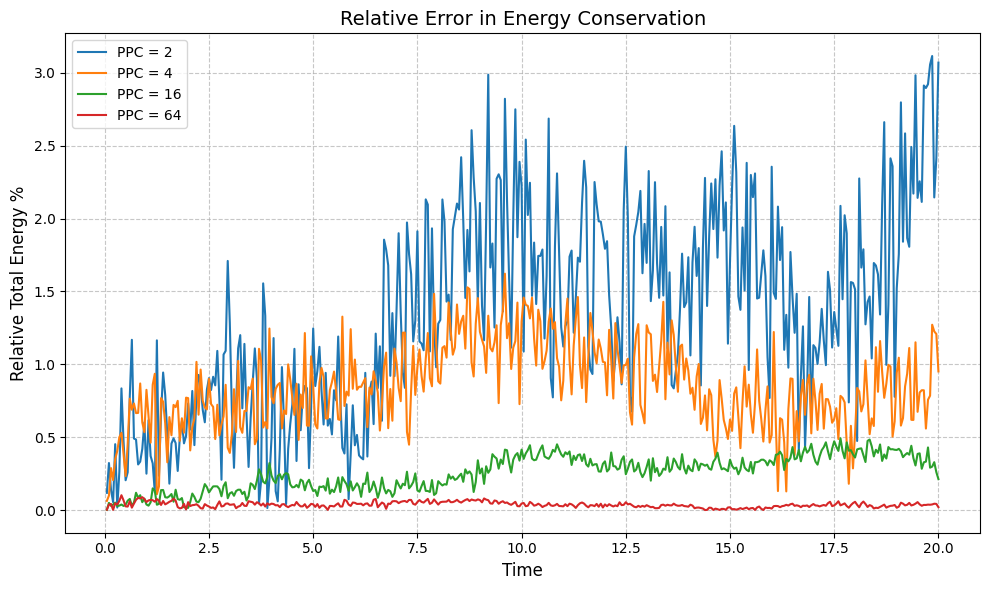

In [ ]:
# ---------------------------------------------------------
# بخش رسم نمودار مقایسه‌ای خطای انرژی
# ---------------------------------------------------------

ppc_values = [2, 4, 16, 64] # مقادیر مختلف برای مقایسه
plt.figure(figsize=(10, 6))

for p in ppc_values:

    temp_solver = VlasovPoisson1D1V_PPT(nx, nv, Lx, vmin, vmax, dt, ppc=p, seed=1)
    set_initial_distribution(temp_solver, f0)
    initialize_leapfrog(temp_solver)

    E0 = total_energy(temp_solver)
    errors = []
    times = []


    for n in range(400):
        step(temp_solver)
        Et = total_energy(temp_solver)


        rel_err_pct = 100.0 * abs(Et - E0) / abs(E0)

        errors.append(rel_err_pct)
        times.append((n + 1) * dt)


    plt.plot(times, errors, label=f'PPC = {p}')

plt.xlabel('Time', fontsize=12)
plt.ylabel('Relative Total Energy %', fontsize=12)
plt.title('Relative Error in Energy Conservation', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Recurrence Analysis in 1D1V Vlasov–Poisson Simulation

## Physical Background

In collisionless plasma simulations, the Vlasov equation predicts phase mixing and Landau damping of the electric field.
However, when the velocity space is discretized using a finite number of phase points, the system may exhibit a *numerical recurrence*.

Recurrence is not a physical phenomenon.  
It is a numerical artifact caused by the finite resolution in velocity space.

After sufficient phase mixing, the discrete velocity representation can cause the system to approximately reconstruct its initial state, leading to a regrowth of the electric field.

---

## Theoretical Recurrence Time

For a perturbation with wave number

\begin{equation}
k = \frac{2\pi}{L},
\end{equation}

the approximate recurrence time is given by:

\begin{equation}
T_{rec} \approx \frac{2\pi}{k \Delta v},
\end{equation}

where:

 ( L ) is the spatial domain length

\begin{equation}
( \Delta v )  
\end{equation}is the effective velocity spacing

\begin{equation}
( \Delta v \sim \frac{v_{max} - v_{min}}{N_{pv}} )
\end{equation}
\begin{equation}
 ( N_{pv} )  
\end{equation}is the number of phase points in velocity direction.

Thus,
\begin{equation}
T_{rec} \propto \frac{1}{\Delta v}.
\end{equation}
Increasing the number of velocity phase points reduces \( \Delta v \) and therefore delays recurrence.

---

## Numerical Detection Strategy

To detect recurrence in the simulation, we monitor:

- The maximum electric field amplitude:  
  \begin{equation}
  max_x |E(x,t)|
  \end{equation}

Recurrence is identified when:

- The electric field initially decays (Landau damping),
- Then regrows after a certain time.

The observed regrowth time is compared with the theoretical estimate
\begin{equation}
( T_rec  ).
\end{equation}

---

## Important Observations

- Recurrence is stronger when phase points are placed on a regular grid.
- Random jitter in initial positions reduces coherence and suppresses recurrence.
- Increasing PPC (particles per cell) delays recurrence.
- Smoothing methods (e.g., void filling) introduce numerical diffusion that can reduce recurrence effects.

---

## Conclusion

Recurrence is a purely numerical effect arising from finite velocity resolution.
It provides an important diagnostic tool for evaluating phase-space resolution and convergence properties of Vlasov solvers.

A well-resolved simulation should push the recurrence time far beyond the physically relevant simulation interval.

In [ ]:
# ============================================================
#                 RECURRENCE ANALYSIS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ---- Extract parameters from your simulation object ----
L = sim.L
vmin = sim.vmin
vmax = sim.vmax
Npv = sim.Npv

k = 2*np.pi / L
dv = (vmax - vmin) / Npv
T_rec_theory = 2*np.pi / (k * dv)

print("Theoretical Recurrence Time ≈", T_rec_theory)

# ---- Convert stored histories ----
E_max_array = np.array(E_max_history)
time_array = np.array(time_array)

# ---- Detect recurrence numerically ----
E0 = E_max_array[0]
threshold = 0.5 * E0

T_rec_numerical = None

for i in range(len(E_max_array)):
    if time_array[i] > 1.5 and E_max_array[i] > threshold:
        T_rec_numerical = time_array[i]
        break

if T_rec_numerical:
    print("Numerical Recurrence detected at t ≈", T_rec_numerical)
else:
    print("No clear recurrence detected.")

# ---- Plot ----
plt.figure(figsize=(7,5))
plt.semilogy(time_array, E_max_array, label="Max |E|")

plt.axvline(T_rec_theory, linestyle='--', label="T_rec (theory)")

if T_rec_numerical:
    plt.axvline(T_rec_numerical, linestyle=':', label="T_rec (numerical)")

plt.xlabel("Time")
plt.ylabel("Max |E|")
plt.title("Recurrence Analysis")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'sim' is not defined

In [ ]:
plt.figure(figsize=(8,5))

# منحنی عددی
plt.plot(time_list, log_rho_max, 'k-', lw=1.5, label='Numerical')

# منحنی تحلیلی Landau damping
k = 1.0   # چون perturbation تو cos(kx) با k=1 بود
alpha = 0.1
A = alpha   # دامنه اولیه
analytic = np.log(A * np.exp(-0.5 * (k**2) * (np.array(time_list)**2)))

plt.plot(time_list, analytic, 'k--', lw=1.2, label='Analytic  exp(-k^2 t^2 / 2)')

plt.xlabel("Time")
plt.ylabel("log(max |ρ|)")
plt.title("Recurrence Plot — Matching Pohn et al. (2005)")
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()